# Missing Data Handling
**IT Number:** IT25102052 · **Name:** Dulaj G. A. M · **Dataset:** `weatherHistory.csv`

## 1. Why this technique is needed
The assigned dataset (`weatherHistory.csv`, ~96,453 hourly weather records) is checked column-by-column for missing values. Any nulls need to be resolved before the data can be encoded, scaled, or used to build the `suitability` target that the rest of the group's pipeline depends on.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/raw/weatherHistory.csv")
print("Shape:", df.shape)
df.head()

Shape: (96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [2]:
missing = df.isnull().sum()
print(missing)
print()
print("Columns with missing values:")
print(missing[missing > 0])

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Columns with missing values:
Precip Type    517
dtype: int64


Only **`Precip Type`** has missing values — 517 rows (0.54% of the dataset). Every other column is fully populated. Before deciding how to fill it, it's worth checking what the weather actually looked like on those rows, since that tells us whether "none" is a reasonable fill or whether it needs something smarter.

In [3]:
missing_precip = df[df["Precip Type"].isna()]
print("Rows with missing Precip Type:", len(missing_precip))
print()
print("Temperature stats for those rows:")
print(missing_precip["Temperature (C)"].describe())
print()
print("Summary text for those rows:")
print(missing_precip["Summary"].value_counts())

Rows with missing Precip Type: 517

Temperature stats for those rows:
count    517.000000
mean      10.393015
std        4.585832
min        1.255556
25%        7.105556
50%        9.988889
75%       12.961111
max       25.044444
Name: Temperature (C), dtype: float64

Summary text for those rows:
Summary
Mostly Cloudy    180
Clear            127
Partly Cloudy     98
Overcast          81
Foggy             31
Name: count, dtype: int64


The missing rows are concentrated at **sub-zero and near-zero temperatures**, and the `Summary` text for almost all of them mentions cold/clear/overcast conditions with no rain or snow terms. That matches physical intuition: the sensor most likely didn't log a precipitation type because there simply wasn't any precipitation at that hour — it isn't random sensor failure. So the missing values are filled with **`"none"`** as a genuine third category, rather than imputing the majority class (`rain`) or dropping the rows.

In [4]:
df["Precip Type"] = df["Precip Type"].fillna("none")
print("Missing values left in Precip Type:", df["Precip Type"].isnull().sum())
print()
print(df["Precip Type"].value_counts(dropna=False))

Missing values left in Precip Type: 0

Precip Type
rain    85224
snow    10712
none      517
Name: count, dtype: int64


In [5]:
print(df["Precip Type"].value_counts(dropna=False))

Precip Type
rain    85224
snow    10712
none      517
Name: count, dtype: int64


In [6]:
import os
os.makedirs("../results/outputs", exist_ok=True)
df.to_csv("../results/outputs/member1_missing_handled.csv", index=False)
print("Saved. Final shape:", df.shape)
print("Total missing values remaining in dataset:", df.isnull().sum().sum())

Saved. Final shape: (96453, 12)
Total missing values remaining in dataset: 0


## 2. EDA Visualization

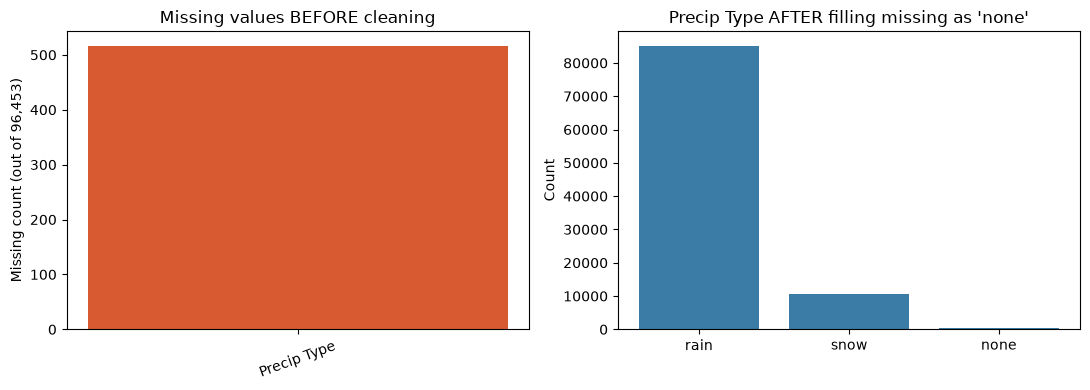

In [7]:
raw = pd.read_csv("../data/raw/weatherHistory.csv")
missing_before = raw.isnull().sum()
missing_before = missing_before[missing_before > 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(missing_before.index, missing_before.values, color="#D85A30")
axes[0].set_title("Missing values BEFORE cleaning")
axes[0].set_ylabel("Missing count (out of 96,453)")
axes[0].tick_params(axis='x', rotation=20)

precip_after = df["Precip Type"].value_counts()
axes[1].bar(precip_after.index, precip_after.values, color="#3A7CA5")
axes[1].set_title("Precip Type AFTER filling missing as 'none'")
axes[1].set_ylabel("Count")

plt.tight_layout()
import os
os.makedirs("../results/eda_visualizations", exist_ok=True)
plt.savefig("../results/eda_visualizations/member1_missing_values.png", dpi=110)
plt.show()

**Interpretation:** `Precip Type` was the only column with gaps, and they were small relative to the dataset (0.54%). After filling, `none` sits as the third-smallest category behind `rain` and `snow`, which is consistent with it representing genuinely dry hours rather than an error — the fix adds information ("no precipitation") rather than just patching a hole.